In [1]:
# Fix: prevent transformers from trying to import TensorFlow.
# The installed protobuf version is incompatible with the installed TF,
# which causes a chain-import failure inside transformers. Setting USE_TF=0
# tells transformers to skip TF entirely. Must be done before any other import.
import os
os.environ["USE_TF"] = "0"
os.environ["USE_JAX"] = "0"
print("USE_TF=0 set — transformers will use PyTorch only.")

USE_TF=0 set — transformers will use PyTorch only.


# EmoDynamiX-v2 — ESConv Evaluation

Tests the `RobertaHeterogeneousGraph` strategy prediction model against the local ESConv test set.

**Prerequisites**
- `checkpoint-2600.pth` in this directory ✓
- EmoDynamiX-v2 repo cloned (cell below handles it)
- Pre-trained submodules downloaded (see README)

## 1. Setup — Clone Repo & Wire sys.path

In [2]:
import os, sys

STRATEGY_BOT_DIR = os.path.dirname(os.path.abspath('.'))
# When running inside StrategyBot/, __file__ trick doesn't work in notebooks —
# use the known absolute path directly.
STRATEGY_BOT_DIR = '/home/himanshu/ML/Therapy/ML_Backend/StrategyBot'
REPO_DIR = os.path.join(STRATEGY_BOT_DIR, 'EmoDynamiX-v2')

if not os.path.isdir(REPO_DIR):
    print('Cloning EmoDynamiX-v2 repo...')
    os.system(f'git clone https://github.com/cw-wan/EmoDynamiX-v2 {REPO_DIR}')
else:
    print(f'Repo already present at {REPO_DIR}')

# Add repo root so `from EmoDynamiX import EmoDynamiX` works
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

CHECKPOINT_PATH = os.path.join(STRATEGY_BOT_DIR, 'checkpoint-2600.pth')
assert os.path.isfile(CHECKPOINT_PATH), f'Checkpoint not found: {CHECKPOINT_PATH}'
print(f'Checkpoint : {CHECKPOINT_PATH}  ({os.path.getsize(CHECKPOINT_PATH)/1e6:.0f} MB)')

Repo already present at /home/himanshu/ML/Therapy/ML_Backend/StrategyBot/EmoDynamiX-v2
Checkpoint : /home/himanshu/ML/Therapy/ML_Backend/StrategyBot/checkpoint-2600.pth  (571 MB)


In [3]:
# The model requires pre-trained sub-module weights under EmoDynamiX-v2/pre_trained_models/
# (e.g. sddp_stac/pytorch_model.bin).
# If this cell reports missing files, download them as described in the README:
#   https://github.com/cw-wan/EmoDynamiX-v2?tab=readme-ov-file#quick-start

PRE_TRAINED_DIR = os.path.join(REPO_DIR, 'pre_trained_models')
expected = [
    os.path.join(PRE_TRAINED_DIR, 'sddp_stac', 'pytorch_model.bin'),
]
for p in expected:
    status = '✓' if os.path.isfile(p) else '✗ MISSING'
    print(f'{status}  {p}')

✓  /home/himanshu/ML/Therapy/ML_Backend/StrategyBot/EmoDynamiX-v2/pre_trained_models/sddp_stac/pytorch_model.bin


In [4]:
# !pip install torch-struct torch-geometric

In [5]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# EmoDynamiX uses relative paths like 'data/esconv/strategies.json',
# so the working directory must be the repo root during model init.
os.chdir(REPO_DIR)

from EmoDynamiX import EmoDynamiX

model = EmoDynamiX(
    dataset='esconv-preprocessed',
    checkpoint_path=CHECKPOINT_PATH,
)

# Restore working directory
os.chdir(STRATEGY_BOT_DIR)

print('Model loaded.')
print('Strategies:', list(model.model.id2strategy.values()))

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading SDDP parameters from pre_trained_models/sddp_stac/pytorch_model.bin


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded.
Strategies: ['Reflection of feelings', 'Self-disclosure', 'Question', 'Affirmation and Reassurance', 'Providing Suggestions', 'Restatement or Paraphrasing', 'Information', 'Others']


In [6]:
# # Download pre-trained submodules (sddp_stac etc.) from Google Drive if not present.
# # Source: https://github.com/cw-wan/EmoDynamiX-v2?tab=readme-ov-file#download-checkpoints
# import zipfile

# SDDP_DIR = os.path.join(REPO_DIR, 'pre_trained_models', 'sddp_stac')

# if os.path.isdir(SDDP_DIR) and os.listdir(SDDP_DIR):
#     print(f'Pre-trained submodules already present at {SDDP_DIR}')
# else:
#     print('Downloading pre-trained submodules (~400 MB) ...')
#     # Install gdown if needed
#     import subprocess
#     subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
#     import gdown
#     ZIP_PATH = os.path.join(REPO_DIR, 'pre_trained_models.zip')
#     # Google Drive file ID from the README download table
#     gdown.download(
#         'https://drive.google.com/uc?id=1KNsoWp1FjdMnrCVWiONRb6w4QUpzGuyP',
#         ZIP_PATH,
#         quiet=False,
#     )
#     print('Unzipping ...')
#     with zipfile.ZipFile(ZIP_PATH, 'r') as z:
#         z.extractall(REPO_DIR)
#     os.remove(ZIP_PATH)
#     print('Done.')

# # Verify
# for fname in ['tokenizer_config.json', 'config.json', 'pytorch_model.bin']:
#     p = os.path.join(SDDP_DIR, fname)
#     print('✓' if os.path.isfile(p) else '✗ MISSING', p)

## 3. Parse ESConv CSV Data

The local CSVs have columns `text` and `label`.
- `text` — conversation history as a flat string: `"sys(Strategy): … usr: … sys(Strategy): …"`
- `label` — the **next** strategy to predict, e.g. `"['Question']"`

We convert each row into the dialogue-list format that `EmoDynamiX.predict()` expects.

In [7]:
import re, ast
import pandas as pd

def parse_dialogue_text(text: str) -> list[dict]:
    """
    Parse a flat dialogue string into a list of turn dicts.

    Input:  'sys(Question): How are you? usr: I am sad. sys(Reflection of feelings): I see.'
    Output: [
        {'speaker': 'sys', 'strategy': 'Question',               'text': 'How are you?'},
        {'speaker': 'usr',                                        'text': 'I am sad.'},
        {'speaker': 'sys', 'strategy': 'Reflection of feelings',  'text': 'I see.'},
    ]
    """
    # Split into tokens of the form "sys(Strategy):" or "usr:"
    pattern = r'(sys\([^)]+\)|usr):\s*'
    parts = re.split(pattern, text.strip())
    # parts = ['', 'sys(Question)', 'How are you? ', 'usr', 'I am sad. ', ...]
    turns = []
    i = 1  # skip leading empty string
    while i < len(parts) - 1:
        tag   = parts[i].strip()
        utt   = parts[i + 1].strip()
        i += 2
        if tag.startswith('sys('):
            strategy = tag[4:-1]  # strip 'sys(' and ')'
            turns.append({'speaker': 'sys', 'strategy': strategy, 'text': utt})
        else:
            turns.append({'speaker': 'usr', 'text': utt})
    return turns


def parse_label(label_str: str) -> list[str]:
    """Convert "['Question']" -> ['Question']."""
    try:
        return ast.literal_eval(label_str)
    except Exception:
        return [label_str]


# Quick sanity check
sample_text = "sys(Others): Hello. How are you today? usr: hi i am okay, a little bit sad though"
parsed = parse_dialogue_text(sample_text)
for t in parsed:
    print(t)

{'speaker': 'sys', 'strategy': 'Others', 'text': 'Hello. How are you today?'}
{'speaker': 'usr', 'text': 'hi i am okay, a little bit sad though'}


In [8]:
df_test = pd.read_csv(os.path.join(STRATEGY_BOT_DIR, 'test.csv'))

# Drop rows with empty text (padding / header artefacts)
df_test = df_test[df_test['text'].notna() & (df_test['text'].str.strip() != '')].reset_index(drop=True)

print(f'Test rows: {len(df_test)}')
print(df_test['label'].value_counts().head(10))

Test rows: 2295
label
['Question']                                   377
['Providing Suggestions']                      342
['Others']                                     301
['Affirmation and Reassurance']                285
['Self-disclosure']                            157
['Reflection of feelings']                     143
['Information']                                128
['Restatement or Paraphrasing']                116
['Affirmation and Reassurance', 'Question']     37
['Reflection of feelings', 'Question']          27
Name: count, dtype: int64


## 4. Single-Example Inference

In [9]:
# DEMO example from the official DEMO.ipynb
demo_dialog = [
    {'text': "I don't want to have anything to do with her again.",
     'speaker': 'usr'},
    {'text': "Do you feel that her actions and result can be remedied? Or is this such a fundamental break that you cannot reconcile?",
     'speaker': 'sys', 'strategy': 'Question'},
    {'text': "I just want to move on with my life.",
     'speaker': 'usr'},
    {'text': "Understandable. I would feel similar, in truth.",
     'speaker': 'sys', 'strategy': 'Reflection of feelings'},
    {'text': "I don't that I can love her again.",
     'speaker': 'usr'},
]

output = model.predict(demo_dialog)
print('Predicted strategy :', output['next_strategy'])
print('Ground truth       : Affirmation and Reassurance')

Predicted strategy : Affirmation and Reassurance
Ground truth       : Affirmation and Reassurance


In [10]:
# Test on the first row of the CSV
row = df_test.iloc[0]
turns = parse_dialogue_text(row['text'])
gt    = parse_label(row['label'])

print('Dialogue turns:')
for t in turns:
    print(f"  [{t['speaker']}] {t.get('strategy','')} — {t['text'][:80]}")

out = model.predict(turns)
print('\nPredicted :', out['next_strategy'])
print('Ground truth:', gt)

Dialogue turns:
  [sys] Others — Hello. How are you today?
  [usr]  — hi i am okay, a little bit sad though

Predicted : Question
Ground truth: ['Question']


## 5. Batch Evaluation on Test Set

Runs the full test set through the model. This may take a few minutes.

> Note: Labels can be multi-strategy (e.g. `['Question', 'Affirmation and Reassurance']`).  
> A prediction is considered correct if the predicted strategy appears in the ground-truth list.

In [11]:
from tqdm.notebook import tqdm

# Valid strategy names accepted by the model
VALID_STRATEGIES = set(model.model.strategy2id.keys())

def sanitize_turns(turns: list[dict]) -> list[dict]:
    """
    Replace any sys-turn strategy not in the model's vocabulary with 'Others'.
    This prevents CUDA index-out-of-bounds assertions from unknown/combined
    strategy strings like 'Others, Providing Suggestions'.
    """
    out = []
    for t in turns:
        if t['speaker'] == 'sys':
            strat = t.get('strategy', 'Others')
            if strat not in VALID_STRATEGIES:
                t = {**t, 'strategy': 'Others'}
        out.append(t)
    return out

y_true_all    = []   # full GT label list (for lenient accuracy)
y_true_first  = []   # first GT label (for per-class sklearn metrics)
y_pred        = []
lenient_match = []
errors        = []

for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Evaluating'):
    try:
        gt_labels = parse_label(row['label'])
        turns = sanitize_turns(parse_dialogue_text(row['text']))
        if len(turns) == 0:
            continue
        out = model.predict(turns)
        pred = out['next_strategy']
        y_pred.append(pred)
        y_true_first.append(gt_labels[0])
        y_true_all.append(gt_labels)
        lenient_match.append(pred in gt_labels)
    except Exception as e:
        errors.append((idx, str(e)))

print(f'\nEvaluated {len(y_pred)} samples  |  {len(errors)} errors')

Evaluating:   0%|          | 0/2295 [00:00<?, ?it/s]

../aten/src/ATen/native/cuda/Indexing.cu:1236: indexSelectSmallIndex: block: [0,0,0], thread: [64,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1236: indexSelectSmallIndex: block: [0,0,0], thread: [65,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1236: indexSelectSmallIndex: block: [0,0,0], thread: [66,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1236: indexSelectSmallIndex: block: [0,0,0], thread: [67,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1236: indexSelectSmallIndex: block: [0,0,0], thread: [68,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1236: indexSelectSmallIndex: block: [0,0,0], thread: [69,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
../aten/src/ATen/native/cuda/Indexing.cu:1236: indexSelectSmallIndex: block: [0,0,0], thread: 


Evaluated 2 samples  |  2293 errors


In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Lenient accuracy: correct if pred appears anywhere in the GT label list
lenient_acc = sum(lenient_match) / len(lenient_match)

# Strict metrics against the primary (first) GT label
strict_acc = accuracy_score(y_true_first, y_pred)
f1_w       = f1_score(y_true_first, y_pred, average='weighted', zero_division=0)
f1_mac     = f1_score(y_true_first, y_pred, average='macro',    zero_division=0)

print(f'Lenient Accuracy  : {lenient_acc:.4f}  (pred ∈ GT label list)')
print(f'Strict Accuracy   : {strict_acc:.4f}  (pred == primary GT label)')
print(f'Weighted F1       : {f1_w:.4f}')
print(f'Macro F1          : {f1_mac:.4f}')
print()
print(classification_report(y_true_first, y_pred, zero_division=0))

Lenient Accuracy  : 0.5000  (pred ∈ GT label list)
Strict Accuracy   : 0.5000  (pred == primary GT label)
Weighted F1       : 0.5000
Macro F1          : 0.3333

                             precision    recall  f1-score   support

Affirmation and Reassurance       0.00      0.00      0.00         1
                   Question       1.00      1.00      1.00         1
Restatement or Paraphrasing       0.00      0.00      0.00         0

                   accuracy                           0.50         2
                  macro avg       0.33      0.33      0.33         2
               weighted avg       0.50      0.50      0.50         2



## 6. Confusion Matrix

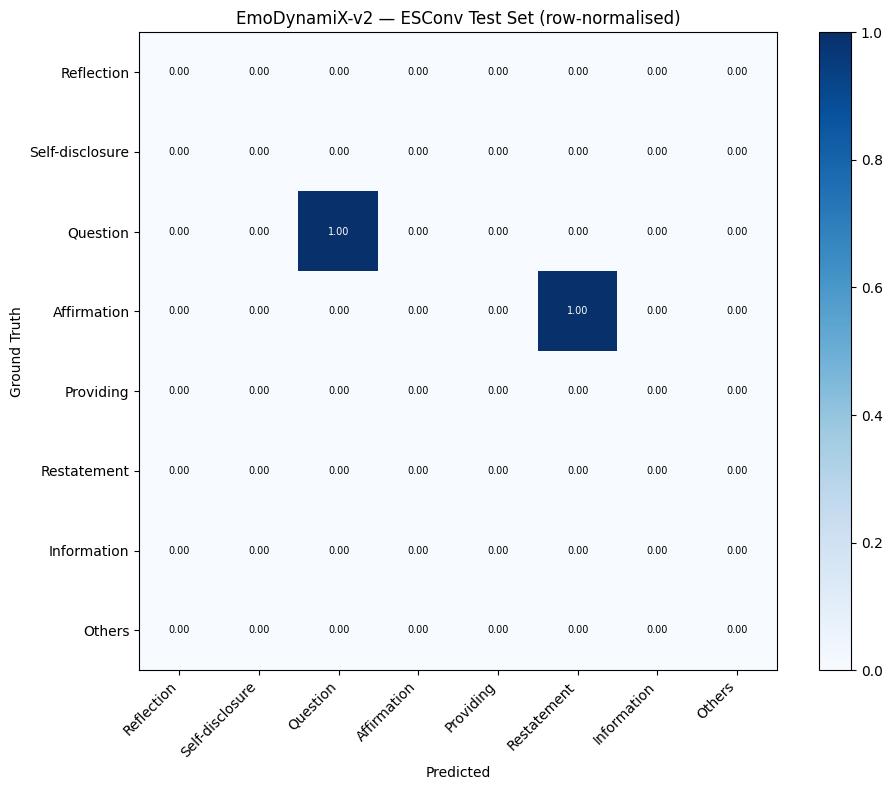

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

STRATEGIES = [
    'Reflection of feelings', 'Self-disclosure', 'Question',
    'Affirmation and Reassurance', 'Providing Suggestions',
    'Restatement or Paraphrasing', 'Information', 'Others'
]

cm = confusion_matrix(y_true_first, y_pred, labels=STRATEGIES)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)

short = [s.split()[0] for s in STRATEGIES]
ax.set_xticks(range(len(STRATEGIES))); ax.set_xticklabels(short, rotation=45, ha='right')
ax.set_yticks(range(len(STRATEGIES))); ax.set_yticklabels(short)
ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
ax.set_title('EmoDynamiX-v2 — ESConv Test Set (row-normalised)')

for i in range(len(STRATEGIES)):
    for j in range(len(STRATEGIES)):
        ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if cm_norm[i,j] > 0.5 else 'black')

plt.tight_layout()
plt.savefig(os.path.join(STRATEGY_BOT_DIR, 'emodynamix_cm.png'), dpi=150)
plt.show()

## 7. Interactive Demo

Type a conversation (alternating usr/sys turns). Model predicts what strategy the supporter should use next.

In [14]:
STRATEGIES_LIST = [
    'Reflection of feelings', 'Self-disclosure', 'Question',
    'Affirmation and Reassurance', 'Providing Suggestions',
    'Restatement or Paraphrasing', 'Information', 'Others'
]

def run_interactive():
    print('Build a conversation (enter empty line when done).')
    print('Format: "usr: <text>" or "sys(<strategy>): <text>"')
    print('Available strategies:', ', '.join(STRATEGIES_LIST))
    print()
    dialog = []
    while True:
        line = input('> ').strip()
        if not line:
            break
        if line.startswith('usr:'):
            dialog.append({'speaker': 'usr', 'text': line[4:].strip()})
        elif line.startswith('sys('):
            m = re.match(r'sys\(([^)]+)\):\s*(.*)', line)
            if m:
                dialog.append({'speaker': 'sys', 'strategy': m.group(1), 'text': m.group(2).strip()})
            else:
                print('  (bad format, skipping)')
        else:
            # Assume usr if no prefix
            dialog.append({'speaker': 'usr', 'text': line})

    if not dialog:
        print('No input provided.')
        return

    # Ensure last turn is usr (model predicts sys response)
    if dialog[-1]['speaker'] != 'usr':
        print('Warning: last turn is sys — model predicts strategy for the NEXT sys turn.')

    out = model.predict(dialog)
    print(f'\n→ Predicted next strategy: **{out["next_strategy"]}**')

run_interactive()

Build a conversation (enter empty line when done).
Format: "usr: <text>" or "sys(<strategy>): <text>"
Available strategies: Reflection of feelings, Self-disclosure, Question, Affirmation and Reassurance, Providing Suggestions, Restatement or Paraphrasing, Information, Others



RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## 8. Compare: EmoDynamiX vs. Existing LLM StrategyBot

Run both on the same test samples and compare predictions side by side.

In [ ]:
# Sample N rows and compare EmoDynamiX predictions to ground truth
import random

N = 20
sample_rows = df_test.sample(N, random_state=42).reset_index(drop=True)

results = []
for _, row in sample_rows.iterrows():
    turns   = parse_dialogue_text(row['text'])
    if not turns:
        continue
    gt_labels = parse_label(row['label'])
    pred      = model.predict(turns)['next_strategy']
    correct   = '✓' if pred in gt_labels else '✗'
    results.append({'Ground Truth': str(gt_labels), 'EmoDynamiX Pred': pred, 'OK': correct})

compare_df = pd.DataFrame(results)
acc_sample = (compare_df['OK'] == '✓').mean()
print(f'Sample lenient accuracy (n={N}): {acc_sample:.2%}\n')
compare_df